Model trained successfully.


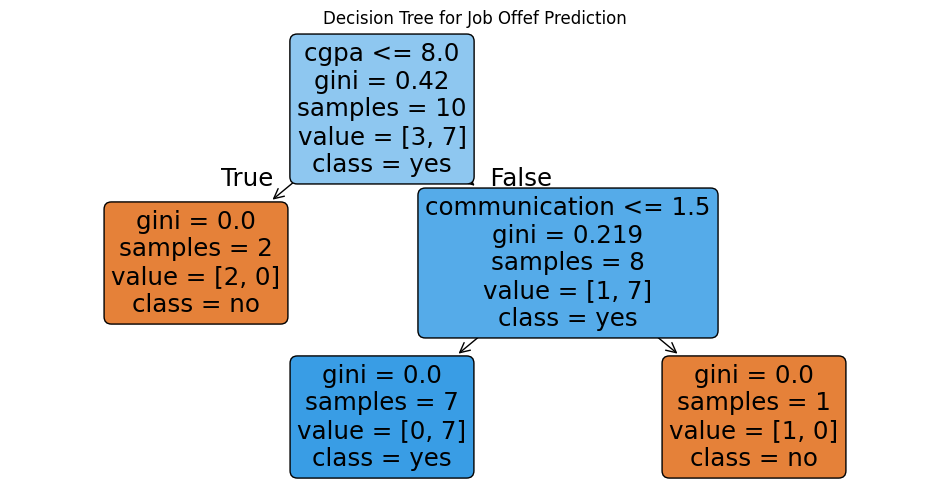

Predicted Job Offer for test sample: no


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder
cancer=load_breast_cancer()
X_cancer=cancer.data
y_cancer=cancer.target
bc_model=DecisionTreeClassifier(max_depth=4,random_state=42)
bc_model.fit(X_cancer,y_cancer)
print("Model trained successfully.")
sample_data=pd.DataFrame({
    'cgpa':[9.2,8.5,9.0,7.5,8.2,9.1,7.8,9.3,8.4,8.6],
    'interactiveness':['yes','no','no','no','yes','yes','yes','yes','no','yes'],
    'practical_knowledge':['verygood','good','average','average','good','good','good','verygood','good','average'],
    'communication':['good','moderate','poor','good','moderate','moderate','poor','good','good','good'],
    'job_offer':['yes','yes','no','no','yes','yes','no','yes','yes','yes']
})
label_encoders={}
for column in ['interactiveness','practical_knowledge','communication','job_offer']:
    le=LabelEncoder()
    sample_data[column]=le.fit_transform(sample_data[column])
    label_encoders[column]=le
X_sample=sample_data.drop('job_offer',axis=1)
y_sample=sample_data['job_offer']
sample_model=DecisionTreeClassifier(max_depth=4,random_state=42)
sample_model.fit(X_sample,y_sample)
plt.figure(figsize=(12,6))
plot_tree(sample_model,feature_names=X_sample.columns,class_names=label_encoders['job_offer'].classes_,filled=True,rounded=True)
plt.title("Decision Tree for Job Offef Prediction")
plt.show()
test_sample=pd.DataFrame([{'cgpa':6.5,'interactiveness':'yes','practical_knowledge':'good','communication':'good'}])
for column in['interactiveness','practical_knowledge','communication']:
  test_sample[column]=label_encoders[column].transform(test_sample[column])
prediction=sample_model.predict(test_sample)
predicted_label=label_encoders['job_offer'].inverse_transform(prediction)
print("Predicted Job Offer for test sample:",predicted_label[0])